In [ ]:
!pip install networkx tqdm

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import urllib.request
import gzip

In [ ]:
def load_snap_graph(limit_edges=None):
    url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
    urllib.request.urlretrieve(url, "graph.txt.gz")

    G = nx.Graph()

    with gzip.open("graph.txt.gz", 'rt') as f:
        for i, line in enumerate(f):
            if limit_edges and i > limit_edges:
                break
            u, v = map(int, line.strip().split())
            G.add_edge(u, v)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G

G = load_snap_graph(limit_edges=100000)  # scalable

Nodes: 4039
Edges: 88234


In [ ]:
def pairwise_connectivity(G):
    total = 0
    for comp in nx.connected_components(G):
        s = len(comp)
        total += s * (s - 1) // 2
    return total

In [ ]:
def pairwise_connectivity(G):
    total = 0
    for comp in nx.connected_components(G):
        s = len(comp)
        total += s * (s - 1) // 2
    return total

In [ ]:
def greedy_cndp(G, k=20, sample_size=1000):
    G = G.copy()
    removed = []
    connectivity_values = []

    nodes = list(G.nodes())

    for step in tqdm(range(k)):
        candidates = random.sample(nodes, min(sample_size, len(nodes)))

        best_node = None
        best_conn = float("inf")

        for v in candidates:
            G_temp = G.copy()
            G_temp.remove_node(v)
            conn = pairwise_connectivity(G_temp)

            if conn < best_conn:
                best_conn = conn
                best_node = v

        G.remove_node(best_node)
        nodes.remove(best_node)

        removed.append(best_node)
        connectivity_values.append(best_conn)

    return removed, connectivity_values

In [ ]:
def degree_baseline(G, k=20):
    G = G.copy()
    nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)
    conn = []

    for i in range(k):
        G.remove_node(nodes[i][0])
        conn.append(pairwise_connectivity(G))

    return conn


def random_baseline(G, k=20):
    G = G.copy()
    nodes = list(G.nodes())
    random.shuffle(nodes)
    conn = []

    for i in range(k):
        G.remove_node(nodes[i])
        conn.append(pairwise_connectivity(G))

    return conn

In [ ]:
k = 20

print("Greedy CNDP...")
_, greedy_conn = greedy_cndp(G, k)

print("Degree...")
degree_conn = degree_baseline(G, k)

print("Random...")
random_conn = random_baseline(G, k)

Greedy CNDP...


100%|██████████| 20/20 [1:29:08<00:00, 267.42s/it]


Degree...
Random...


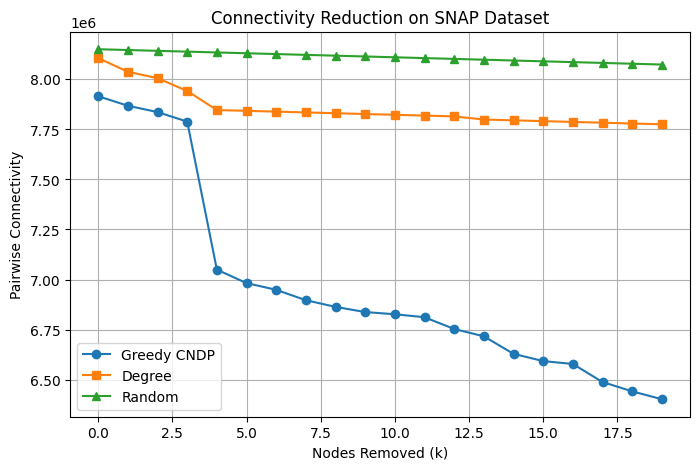

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(greedy_conn, marker='o', label="Greedy CNDP")
plt.plot(degree_conn, marker='s', label="Degree")
plt.plot(random_conn, marker='^', label="Random")

plt.xlabel("Nodes Removed (k)")
plt.ylabel("Pairwise Connectivity")
plt.title("Connectivity Reduction on SNAP Dataset")
plt.legend()
plt.grid()
plt.show()